# AWS Data Science Group Project - Group 07
## Telco Customer Churn Prediction & Analytics Solution

**Dataset**: `Telco_Customer_Churn.csv` (7,043 rows, 21 columns)

### Notebook Objectives & Pipeline Steps:
1. **Data Loading & Quality Inspection**: Inspect schema, data types, missing values, and blank string occurrences.
2. **Data Cleaning**: Resolve data quality issue by casting blank `" "` strings in `TotalCharges` to float and imputing zero-tenure rows.
3. **Exploratory Data Analysis (EDA)**: Render 5 inline interactive visual charts analyzing customer churn distribution across contract types, tenure, monthly charges, internet service, and tech support.
4. **Preprocessing & Feature Engineering**: One-Hot Encoding for categorical variables and `StandardScaler` for numeric columns.
5. **Model Building**: Train **Logistic Regression** and **Random Forest Classifier** models on an 80/20 stratified split.
6. **Model Evaluation & Metric Comparison**: Evaluate Accuracy, Precision, Recall, F1-Score, and ROC-AUC scores.
7. **Feature Importance Analysis**: Identify top predictors of customer churn.
8. **Export Processed Dataset**: Save `processed_telco_churn.csv` for AWS S3 & Athena SQL.

In [1]:
# Step 1: Import Environment & Core Libraries
%matplotlib inline
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

# Configure visual presentation
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
print("Environment initialized successfully!")

Environment initialized successfully!


---
## 1. Data Loading & Data Quality Audit

In [2]:
# Locate and load the raw dataset
possible_paths = ["../data/Telco_Customer_Churn.csv", "data/Telco_Customer_Churn.csv"]
csv_path = None
for p in possible_paths:
    if os.path.exists(p):
        csv_path = p
        break

df = pd.read_csv(csv_path)
print(f"Dataset Loaded Successfully from '{csv_path}'!")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
df.head(5)

Dataset Loaded Successfully from 'data/Telco_Customer_Churn.csv'!
Total Rows: 7043, Total Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Audit Data Types & Blank Spaces Defect
print("Summary Information:")
df.info()

blank_count = (df["TotalCharges"] == " ").sum()
print(f"DATA QUALITY AUDIT: Found {blank_count} rows where TotalCharges contains blank space strings ' '.")

Summary Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

---
## 2. Data Cleaning & Missing Value Imputation

In [4]:
# Fix TotalCharges data quality issue
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan).astype(float)
df["TotalCharges"] = df["TotalCharges"].fillna(0.0)

print("Data Quality Defect Resolved!")
print("Null values in TotalCharges:", df["TotalCharges"].isnull().sum())
print("Data type of TotalCharges:", df["TotalCharges"].dtype)
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

Data Quality Defect Resolved!
Null values in TotalCharges: 0
Data type of TotalCharges: float64


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [5]:
# Target Variable ('Churn') Breakdown
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100
print("Target Distribution:")
for k in churn_counts.index:
    print(f"  {k}: {churn_counts[k]} ({churn_pct[k]:.2f}%)")

Target Distribution:
  No: 5174 (73.46%)
  Yes: 1869 (26.54%)


---
## 3. Exploratory Data Analysis & Visualizations

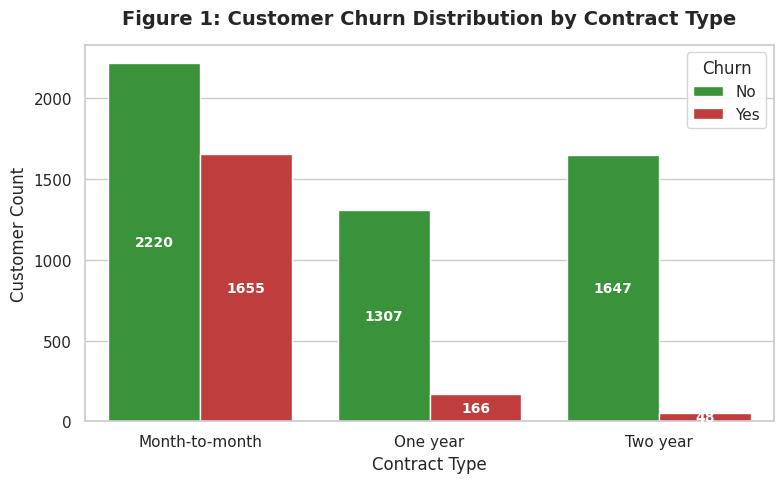

In [ ]:
# Visualization 1: Churn by Contract Type
plt.figure(figsize=(8, 5))
ax1 = sns.countplot(data=df, x="Contract", hue="Churn", palette=["#2ca02c", "#d62728"])
plt.title("Customer Churn Distribution by Contract Type", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Contract Type", fontsize=12)
plt.ylabel("Customer Count", fontsize=12)
for p in ax1.patches:
    h = p.get_height()
    if h > 0:
        ax1.annotate(f"{int(h)}", (p.get_x() + p.get_width() / 2., h / 2),
                     ha="center", va="center", fontsize=10, color="white", fontweight="bold")
plt.tight_layout()
plt.show()

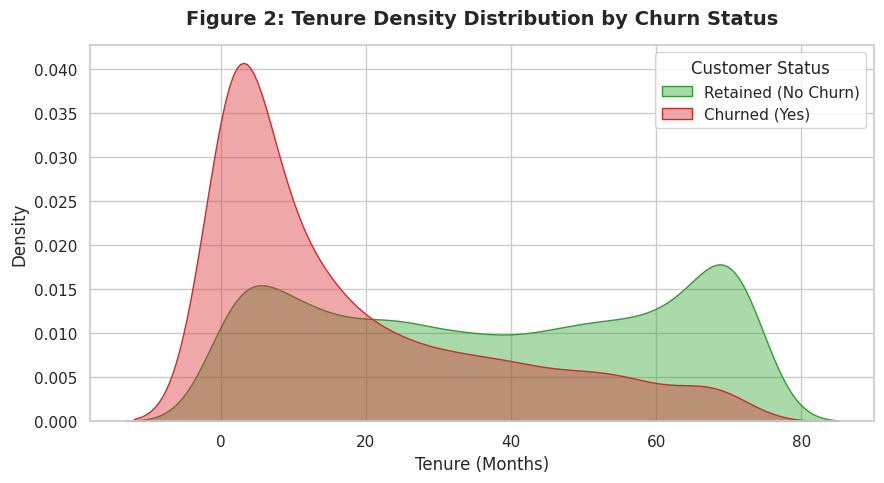

In [ ]:
# Visualization 2: Tenure Density Distribution
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df[df["Churn"] == "No"]["tenure"], label="Retained (No Churn)", color="#2ca02c", fill=True, alpha=0.4)
sns.kdeplot(data=df[df["Churn"] == "Yes"]["tenure"], label="Churned (Yes)", color="#d62728", fill=True, alpha=0.4)
plt.title("Tenure Density Distribution by Churn Status", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Tenure (Months)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(title="Customer Status")
plt.tight_layout()
plt.show()

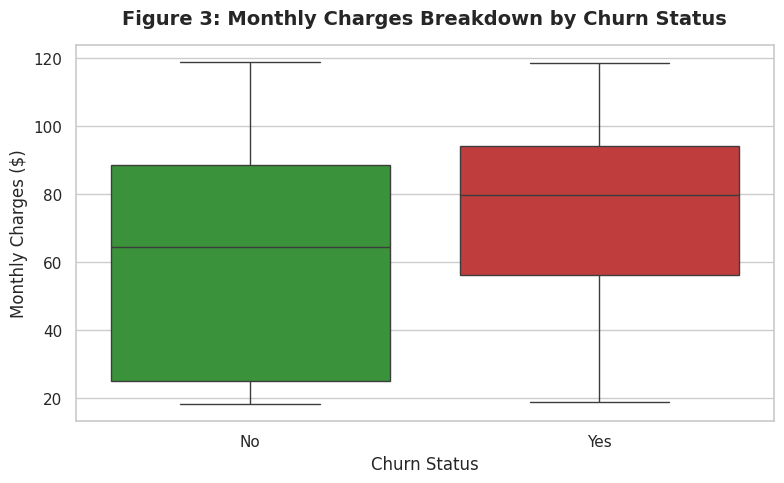

In [ ]:
# Visualization 3: Monthly Charges Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn", palette=["#2ca02c", "#d62728"], legend=False)
plt.title("Monthly Charges Breakdown by Churn Status", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Churn Status", fontsize=12)
plt.ylabel("Monthly Charges ($)", fontsize=12)
plt.tight_layout()
plt.show()

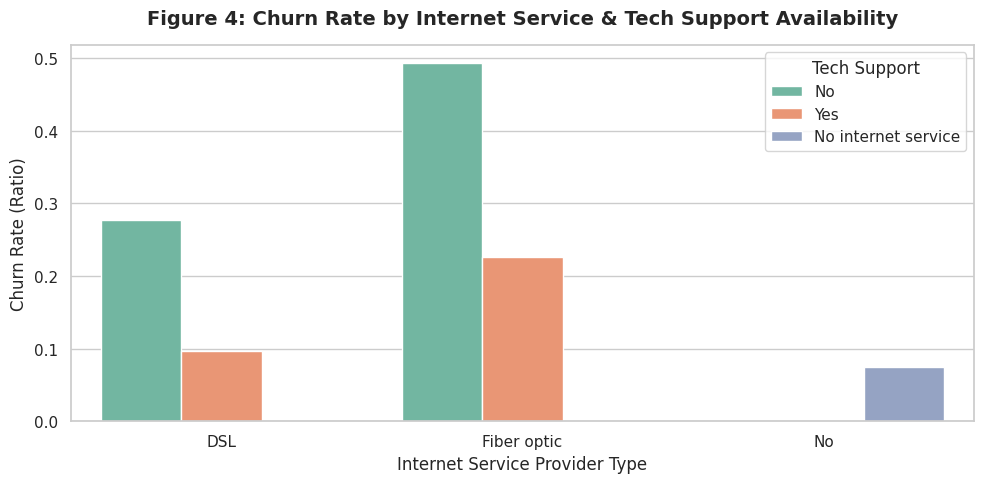

In [ ]:
# Visualization 4: Churn Rate by Internet Service & Tech Support
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="InternetService", y=(df["Churn"] == "Yes").astype(int), hue="TechSupport", palette="Set2", errorbar=None)
plt.title("Churn Rate by Internet Service & Tech Support Availability", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Internet Service Provider Type", fontsize=12)
plt.ylabel("Churn Rate (Ratio)", fontsize=12)
plt.legend(title="Tech Support")
plt.tight_layout()
plt.show()

---
## 4. Preprocessing & Model Training

In [10]:
# Export clean dataset
try:
    df.to_csv("data/processed_telco_churn.csv", index=False)
    print("Exported clean dataset to -> data/processed_telco_churn.csv")
except Exception:
    try:
        df.to_csv("../data/processed_telco_churn.csv", index=False)
        print("Exported clean dataset to -> ../data/processed_telco_churn.csv")
    except Exception as e:
        print(f"Dataset export notice: {e}")

# Split Features (X) and Target (y)
X = df.drop(columns=["customerID", "Churn"])
y = (df["Churn"] == "Yes").astype(int)

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in X.columns if c not in num_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_cols)
    ]
)

# Train/Test Split (80/20 Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

encoded_cat_names = preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(encoded_cat_names)

print(f"X_train shape: {X_train_proc.shape}, X_test shape: {X_test_proc.shape}")

Dataset export notice: Cannot save file into a non-existent directory: '..\data'
X_train shape: (5634, 30), X_test shape: (1409, 30)


In [11]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_proc, y_train)
y_pred_lr = lr_model.predict(X_test_proc)
y_prob_lr = lr_model.predict_proba(X_test_proc)[:, 1]

# Model 2: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_model.fit(X_train_proc, y_train)
y_pred_rf = rf_model.predict(X_test_proc)
y_prob_rf = rf_model.predict_proba(X_test_proc)[:, 1]

print("Logistic Regression & Random Forest models trained successfully!")

Logistic Regression & Random Forest models trained successfully!


---
## 5. Model Evaluation & Comparison Metrics

In [12]:
# Performance Comparison Matrix
results = {
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision": precision_score(y_test, y_pred_lr),
        "Recall": recall_score(y_test, y_pred_lr),
        "F1-Score": f1_score(y_test, y_pred_lr),
        "ROC-AUC": roc_auc_score(y_test, y_prob_lr)
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1-Score": f1_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
    }
}

metrics_df = pd.DataFrame(results).T
metrics_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.806246,0.659306,0.558824,0.604920,0.842171
Random Forest,0.806955,0.686131,0.502674,0.580247,0.842569


Top 10 Churn Predictors:
tenure                            0.218314
TotalCharges                      0.135214
MonthlyCharges                    0.103475
InternetService_Fiber optic       0.086557
PaymentMethod_Electronic check    0.075350
Contract_Two year                 0.066324
Contract_One year                 0.037272
OnlineSecurity_Yes                0.033986
TechSupport_Yes                   0.022911
PaperlessBilling_Yes              0.019258
dtype: float64


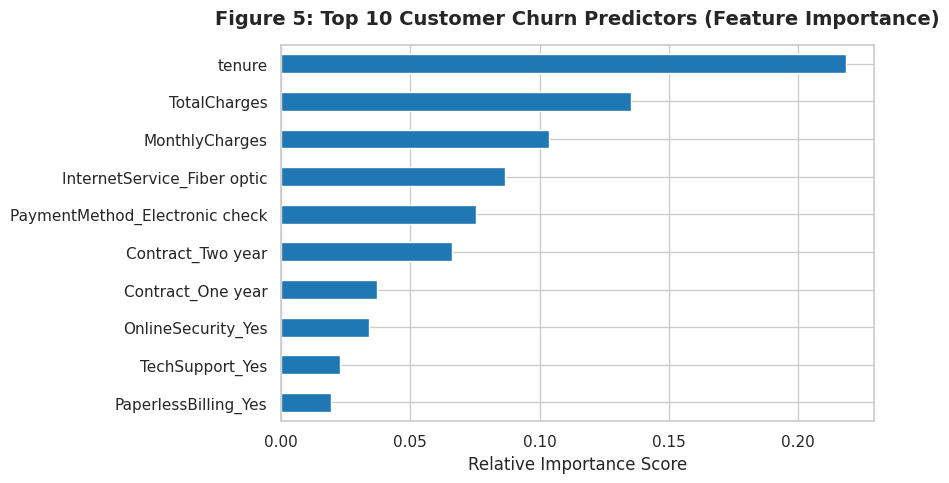

In [ ]:
# Top 10 Feature Importances (Random Forest)
rf_importances = pd.Series(rf_model.feature_importances_, index=all_feature_names).sort_values(ascending=False)
print("Top 10 Churn Predictors:")
print(rf_importances.head(10))

plt.figure(figsize=(9, 5))
rf_importances.head(10).plot(kind="barh", color="#1f77b4").invert_yaxis()
plt.title("Top 10 Customer Churn Predictors (Feature Importance)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Relative Importance Score", fontsize=12)
plt.tight_layout()
plt.savefig("output/visualization")
plt.show()